
## Sensitivity Analysis on AlphaPEM using Sobol Method (N = 1024)

In this notebook, we study how different input parameters affect the behavior of the AlphaPEM model using Sobol sensitivity analysis. The model takes 13 input features, including operating conditions and physical parameters.

To do this, we:

* Generate Sobol samples using the SALib library with a base size of N = 1024.
* Run the AlphaPEM model on these samples to produce polarization curves.
* Compute the area under the polarization curve (AUC) in three regions of current density:

  * ***Activation;*** 0.0 to 0.4 A/cm²
  * ***Ohmic:*** 0.4 to 1.6 A/cm²
  * ***Mass transport:*** above 1.6 A/cm²
* Use these regional AUCs as the target outputs for sensitivity analysis.

If the cell voltage becomes negative during simulation, we treat it as zero from that point onward. This makes sure the AUC values reflect only physically meaningful parts of the curve.

This helps us understand which inputs matter the most in each current density region of the fuel cell's operation.


In [17]:
import os
import sys
import hashlib
import pickle

# For data science in general
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


# Sensitivity Analysis (SALib) 
from SALib.sample.sobol import sample as sobol_sample
from SALib.analyze import sobol

# Modeling
import xgboost as xgb

# Handling configurations 
from omegaconf import OmegaConf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="SALib")

# Modules from our project
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves
from src.utils.FE_formatting import expand_column_to_columns
from src.utils.FE_imputation import compute_nearest_neighbors,aggregate_knn_curves
from src.utils.auxiliar_func_FE import compute_region_auc,add_confidence_intervals,run_sobol_analysis_for_region
from src.utils.auxiliar_func_FE import run_sobol_convergence_analysis,build_sobol_summary_table,plot_sobol_region_barplot,select_top_features
from src.utils.auxiliar_func_FE import load_cv_results,plot_shap_bar,plot_sobol_index_convergence,load_FE_results,save_FE_results
from src.utils.auxiliar_func_FE import  plot_top_k_rankings_across_regions,select_top_features,plot_sobol_ranking

## Utils

In [2]:
# --- Load parameter names from config ---
param_config = OmegaConf.load('../param_config.yaml')
parameter_names = list(param_config.keys())

# Add 'ifc' manually if you ever include it in plots
if 'ifc' not in parameter_names:
    parameter_names.append('ifc')

# --- Define consistent color map for all features ---
COLORS = OmegaConf.load('../configs/colors_cfg.yaml')['COLORS']
FEATURE_COLOR_MAP = {feat: COLORS[i % len(COLORS)] for i, feat in enumerate(parameter_names)}

## Definition of problem + sampling

### Generating Sobol samples

In this step, we create the input samples for sensitivity analysis using the Sobol method.
Sobol sequences are special sets of numbers that cover the space of possible inputs very evenly. This helps us explore the whole range of values for each input parameter without needing too many samples.

We use the `sobol_sample` function from SALib to generate a sample matrix with a base size of `N = 1024`. Each row is one input configuration that we will send to the AlphaPEM model. The result is stored in a DataFrame for easy processing later.


### Cleaning and preparing the samples

Some of our input parameters are discrete (see <code>e</code>), meaning they can only take a few fixed values (like 3, 4, or 5). The Sobol generator gives continuous values, so here we round each sampled value to the nearest valid one for those parameters.

We also add a new input called `Pc_des`, which depends on another input:
`Pc_des = Pa_des - 20000`. This keeps the pressure difference between anode and cathode fixed.

Finally, we create a unique ID (`SHA256`) for every row. This helps us track each input configuration later. We also store the row index to make merging easier.

In [3]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)
unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
id = SA.define_id()
df_param_values_final = SA.apply_dependent_parameters(dependent_parameters)
df_param_values_final["index"] = df_param_values_final.index

In [4]:
df_param_values_final.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,SHA256,Pc_des,index
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,0094c64f8fdda33260ed63c492d142bc880a650b617e77...,248442.555293,0
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,732f012ec39bdcb105868dbabddf45c3d1be6262121e97...,248442.555293,1
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,9cee6cbca778100f2a177430c2227fac9d62d9ba6514c9...,181916.980138,2
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,58549ad37fc1b48d631b9780b6a1302963afea4c952cf9...,248442.555293,3
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,f08c07abbd89c1c9b63fb75cd3c24c5580b1d9dfeeb7e8...,248442.555293,4


### Save the design matrix for sampling

In [5]:
# df_param_values_final.to_pickle("../data/raw/nathaly_sobol_design_matrix.pkl")

## Loading simulation results

We now load the results from the AlphaPEM simulations. These results include the polarization curves: current density (`ifc`) and voltage (`Ucell`) for each configuration. We only keep these two columns and merge them with the original input samples using the `config_id` and `index` columns.

In [6]:
# Load simulated results 
results_path = "../data/raw/sampled_nathaly_sobol_design_matrix_forN1024.pkl"
df_sampled = pd.read_pickle(results_path)

# Keep only the columns we need 
df_sampled_reduced = df_sampled[["SHA256", "index","ifc", "Ucell"]].copy()

# Merge with input samples 
df_merged = pd.merge(
    df_param_values_final,
    df_sampled_reduced,
    on=["SHA256","index"],
    how="left")

print(f"Merged DataFrame has {len(df_merged)} rows.")

# Important: Organize the df in the same order from the design matrix
df_merged = df_merged.sort_values(by = "index")
df_merged.head(3)

Merged DataFrame has 28672 rows.


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,SHA256,Pc_des,index,ifc,Ucell
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,0094c64f8fdda33260ed63c492d142bc880a650b617e77...,248442.555293,0,"[0.0008208004935869315, 0.10081944072368557, 0...","[1.033670888626164, 0.9897184052886249, 0.9578..."
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,732f012ec39bdcb105868dbabddf45c3d1be6262121e97...,248442.555293,1,"[0.0008137945541252691, 0.1008124229812766, 0....","[1.0214271389919458, 0.9758659124214419, 0.942..."
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,9cee6cbca778100f2a177430c2227fac9d62d9ba6514c9...,181916.980138,2,"[0.0008164799253827624, 0.10081511290053446, 0...","[1.0367017913059788, 0.977547607286612, 0.9374..."


In [7]:
print("There are", df_merged["Ucell"].isna().sum(), "missing polarization curves. AlphaPEM didn't run for those configs.")
df_merged.isna().sum()

There are 24 missing polarization curves. AlphaPEM didn't run for those configs.


Tfc             0
Pa_des          0
Sc              0
Phi_c_des       0
epsilon_gdl     0
tau             0
epsilon_mc      0
epsilon_c       0
e               0
Re              0
i0_c_ref        0
kappa_co        0
kappa_c         0
SHA256          0
Pc_des          0
index           0
ifc            24
Ucell          24
dtype: int64

--------------------------------------------------------------------------------------------------------

###  Imputing Missing Polarization Curves Using KNN
In certain Sobol-sampled configurations, the AlphaPEM model failed to produce a valid polarization curve. For these instances, missing Ucell values were imputed using the k-nearest neighbors (KNN) algorithm, following the procedure below:

1. **Detection of Missing Data:** Identify all records with missing `Ucell` values.
2. **Distance Computation:** For each incomplete record, compute the Euclidean distance to all records with valid Ucell values.
3. **Neighbor Selection:** Specify the number of nearest neighbors (k) to be used in the imputation process.
4. **Value Aggregation:** For each `ifc` value, select the *k closest neighbors* and compute the mean of their corresponding voltage values.
5. **Curve Reconstruction:** The averaged voltages are assembled to reconstruct the imputed polarization curve.

We check records without output

In [8]:
none_list =[]
for i, cell in enumerate(df_merged['Ucell']):
    if cell is None:
        none_list.append(i)
print(f'Number records without output {len(none_list)}')
df_merged['flag']  = None
df_merged.iloc[none_list, df_merged.columns.get_loc("flag")] = "no_output"

Number records without output 24


Now we evaluate the valid outputs

In [9]:
df_merged_large_ifc =expand_column_to_columns(df_or=  df_merged,param ='ifc')
df_merged_large =expand_column_to_columns(df_or = df_merged_large_ifc,param ='Ucell')

We run the validation function on the DataFrame because we intend to impute the curve using only the valid polarization curves.

In [10]:
valid_criteria = OmegaConf.load('../configs/valid_polarization_curve_cfg.yaml')
validated_df = validate_polarization_curves(
    df_merged_large,
    apply_criteria=valid_criteria['criteria'],
    filter_invalid=False,
    voltage_range=valid_criteria['voltage_range'],
    approx_monotonic_threshold=valid_criteria['approx_monotonic_threshold']
)
validated_df.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,0.729589,0.720136,0.710694,0.701276,0.691868,0.682447,0.672998,0.663503,0.653945,valid
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,0.714532,0.707312,0.699526,0.691418,0.682971,0.674209,0.665224,0.656077,0.646728,valid
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,0.674898,0.678610,0.672720,0.664524,0.658328,0.651773,0.644676,0.636803,0.628512,valid


In [11]:
crosstab = pd.crosstab(validated_df['flag'].fillna('NA'), validated_df['classification'].fillna('NA'))
crosstab

classification,invalid,valid
flag,,
NA,14,28634
no_output,24,0


In [12]:
validated_df.loc[validated_df.flag=='no_output','classification']= "invalid_no_output"
validated_df= validated_df.drop('flag',axis=1)

In [13]:
print(validated_df.classification.value_counts())
print(validated_df.classification.value_counts(normalize=True))

classification
valid                28634
invalid_no_output       24
invalid                 14
Name: count, dtype: int64
classification
valid                0.998675
invalid_no_output    0.000837
invalid              0.000488
Name: proportion, dtype: float64


###  Imputation process using KNN.

We just calculated those for the instances that we didn't have an output due to computational constrains

In [14]:
nearest_indices, nearest_distances,final_df_valid_cmpl,final_df_no_output_cmpl = compute_nearest_neighbors(df = validated_df, parameter_ranges = parameter_ranges,k=10)

Shape of valid cases: (28634, 13) & shape of no-output cases: (24, 13)
Shape of distance matrix: (24, 28634)


In [18]:

df_knn_missing,ifc_outputs_knn,ucell_outputs_knn = aggregate_knn_curves(df_valid = final_df_valid_cmpl,df_missing=final_df_no_output_cmpl, nearest_indices = nearest_indices,agg_fn='mean')
df_knn_missing.head(3)

,SHA256,index,ifc_0,ifc_1,ifc_2,ifc_3,ifc_4,ifc_5,ifc_6,ifc_7,...,Ucell_21,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30
0,270224541b0577c2209eb38775bac24a95ce68a4438afa...,155,0.000820,0.100819,0.200819,0.300819,0.400819,0.500819,0.600819,0.700819,...,0.587679,0.569962,0.551158,0.531802,0.511553,0.490550,0.468516,0.445770,0.422027,0.397222
1,f8618236b03a059484a214652ca26f19ad809cb3a1ff76...,1162,0.000822,0.100820,0.200820,0.300820,0.400820,0.500820,0.600820,0.700820,...,0.601299,0.588804,0.576235,0.563372,0.550056,0.536143,0.521409,0.505404,0.487052,0.460036
2,1afda288a58c50fdc2b13fc9b1830f5da4768914da6d22...,1163,0.000819,0.100818,0.200818,0.300818,0.400818,0.500818,0.600818,0.700818,...,0.591214,0.579266,0.567994,0.556620,0.544555,0.531696,0.518166,0.504427,0.488914,0.464214


We validate the synthetic curves

In [19]:
validated_df_knn_missing = validate_polarization_curves(
    df_knn_missing,
    apply_criteria=valid_criteria['criteria'],
    filter_invalid=False,
    voltage_range=valid_criteria['voltage_range'],
    approx_monotonic_threshold=valid_criteria['approx_monotonic_threshold']
)
print(f'Agg:{validated_df_knn_missing.classification.value_counts()},{validated_df_knn_missing.classification.value_counts(normalize=True)}')


Agg:classification
valid    24
Name: count, dtype: int64,classification
valid    1.0
Name: proportion, dtype: float64


We assign the sinthetic curve values

In [22]:
final_df_no_output_cmpl['Ucell'] = ucell_outputs_knn
final_df_no_output_cmpl['ifc'] = ifc_outputs_knn

C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_7452\3590569045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_no_output_cmpl['Ucell'] = ucell_outputs_knn
C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_7452\3590569045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_no_output_cmpl['ifc'] = ifc_outputs_knn


Finally we join the dataframe with the original configuration information and the expanded imputed values of `ifc` and `Ucell` for the records with missing current and voltage information

In [23]:
final_df_no_output_cmpl_tmpr = final_df_no_output_cmpl.drop(columns=df_knn_missing.columns.difference(['SHA256', 'index']))
final_df_no_output_cmpl_T = final_df_no_output_cmpl_tmpr.merge(df_knn_missing,on=['SHA256', 'index'], how='left')
final_df_no_output_cmpl_T.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_21,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30
0,351.886845,141620.487841,1.167888,0.61256,0.589951,2.806114,0.166173,0.291489,5,0.000002,...,0.587679,0.569962,0.551158,0.531802,0.511553,0.490550,0.468516,0.445770,0.422027,0.397222
1,358.404637,249665.979687,1.124174,0.39717,0.564333,3.482001,0.295437,0.251682,5,0.000003,...,0.601299,0.588804,0.576235,0.563372,0.550056,0.536143,0.521409,0.505404,0.487052,0.460036
2,347.875597,176506.911116,1.124174,0.39717,0.564333,3.482001,0.295437,0.251682,5,0.000003,...,0.591214,0.579266,0.567994,0.556620,0.544555,0.531696,0.518166,0.504427,0.488914,0.464214


**We unify the valid and invalid curves with the ones we imputed and organized the records by index**

In [24]:
final_df_others_cmpl = validated_df.loc[validated_df.classification!="invalid_no_output"]
final_imputed = pd.concat([final_df_others_cmpl,final_df_no_output_cmpl_T],axis=0)
final_imputed = final_imputed.sort_values(by='index')
final_imputed.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,0.729589,0.720136,0.710694,0.701276,0.691868,0.682447,0.672998,0.663503,0.653945,valid
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,0.714532,0.707312,0.699526,0.691418,0.682971,0.674209,0.665224,0.656077,0.646728,valid
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,0.674898,0.678610,0.672720,0.664524,0.658328,0.651773,0.644676,0.636803,0.628512,valid


In [26]:
pd.DataFrame(final_imputed).to_pickle("../data/raw/sampled_imputed_nathaly_sobol_design_matrix_forN1024.pkl")

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Running Sobol SA on a specific region

We now compute the Sobol sensitivity indices for one region of the polarization curve.
The curve is split into three parts based on current density:

* **Activation region**: 0.0 – 0.4 A/cm²
* **Ohmic region**: 0.4 – 1.6 A/cm²
* **Mass transport region**: above 1.6 A/cm²

We calculate the area under the curve (AUC) for the selected region.
NOTE: If the voltage becomes negative, we set it to zero before computing the AUC.

Finally, we run the Sobol analysis using the AUC as the target and return the full set of sensitivity indices.


In [21]:
ifc_cols = [col for col in df_merged.columns if col.startswith("ifc_")]
ucell_cols = [col for col in df_merged.columns if col.startswith("Ucell_")]

REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

for region_name in REGIONS.keys():
    region_bounds = REGIONS[region_name]   
    target_name = f"AUC_{region_name}"
    print(f"[INFO] Computing AUC target for region: {region_name}")
    df_merged[target_name] = df_merged.apply(
        compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds, "zero")
    )

# VERY IMPORTANT: Organize in the expected order
df_merged = df_merged.sort_values(by = "index")

[INFO] Computing AUC target for region: activation
[INFO] Computing AUC target for region: ohmic
[INFO] Computing AUC target for region: mass_transport


In [22]:
Si_activation, total_Si_activation, first_Si_activation, second_Si_activation = run_sobol_analysis_for_region(df_merged["AUC_activation"], problem, region_name="activation")

[INFO] Running Sobol SA on the AUC of the 'activation' region.

[SUMMARY] Sobol S1 (main effects):
Sum of S1 indices: 0.9701
Sum of S1 indices (setting negative indices to 0): 0.9701

[SUMMARY] Sobol S2 (interaction effects):
Sum of second order: -0.166
Sum of second order (only significant & > 0): 0.0
[WARNING] Some S2 indices are negative!

[SUMMARY] Combined S1 + S2:
Sum of S1 and S2: 0.8041
Sum of significant S1 + significant S2: 0.9701


In [23]:
Si_ohmic, total_Si_ohmic, first_Si_ohmic, second_Si_ohmic = run_sobol_analysis_for_region(df_merged["AUC_ohmic"], problem, region_name="ohmic")

[INFO] Running Sobol SA on the AUC of the 'ohmic' region.

[SUMMARY] Sobol S1 (main effects):
Sum of S1 indices: 0.9303
Sum of S1 indices (setting negative indices to 0): 0.9322
[WARNING] Some S1 indices are negative!

[SUMMARY] Sobol S2 (interaction effects):
Sum of second order: -0.1791
Sum of second order (only significant & > 0): 0.0
[WARNING] Some S2 indices are negative!

[SUMMARY] Combined S1 + S2:
Sum of S1 and S2: 0.7512
Sum of significant S1 + significant S2: 0.9322


In [24]:
Si_mass, total_Si_mass, first_Si_mass, second_Si_mass = run_sobol_analysis_for_region(df_merged["AUC_mass_transport"], problem, region_name="mass_transport")

[INFO] Running Sobol SA on the AUC of the 'mass_transport' region.

[SUMMARY] Sobol S1 (main effects):
Sum of S1 indices: 0.8674
Sum of S1 indices (setting negative indices to 0): 0.8794
[WARNING] Some S1 indices are negative!

[SUMMARY] Sobol S2 (interaction effects):
Sum of second order: -0.1408
Sum of second order (only significant & > 0): 0.0
[WARNING] Some S2 indices are negative!

[SUMMARY] Combined S1 + S2:
Sum of S1 and S2: 0.7266
Sum of significant S1 + significant S2: 0.8794


### Convergence plots

In [26]:
# Run convergence for activation region using ST index
sobol_convergence_activation = run_sobol_convergence_analysis(df_merged["AUC_activation"], problem, step=2, max_N=1024, index_type="ST")
# Run convergence for activation region using ST index
sobol_convergence_ohmic = run_sobol_convergence_analysis(df_merged["AUC_ohmic"], problem, step=2, max_N=1024, index_type="ST")
# Run convergence for activation region using ST index
sobol_convergence_mass = run_sobol_convergence_analysis(df_merged["AUC_mass_transport"], problem, step=2, max_N=1024, index_type="ST")


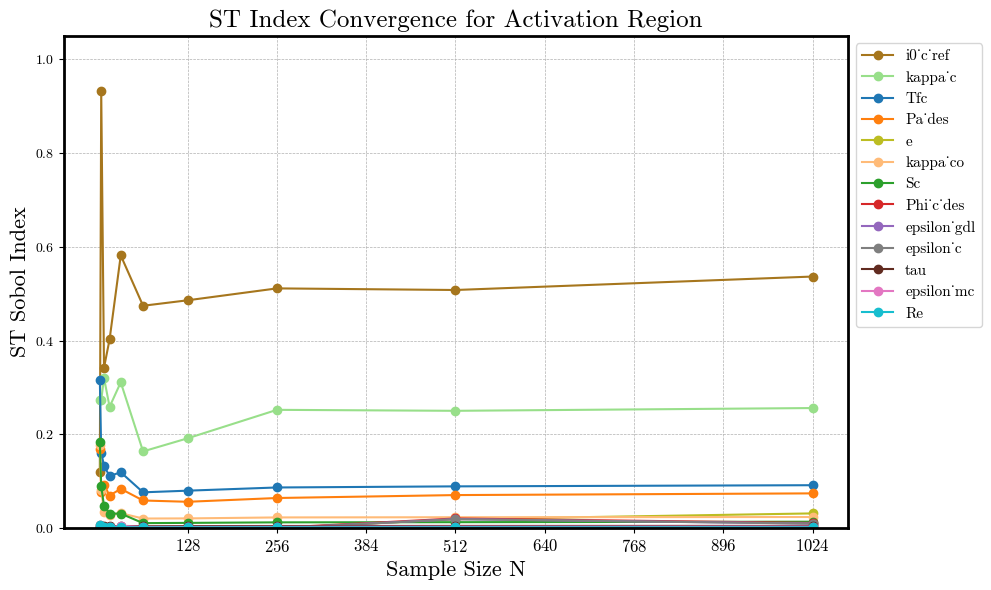

In [36]:
# Plot convergence
plot_sobol_index_convergence(sobol_convergence_activation, index_type="ST", region="activation", top_k=13)

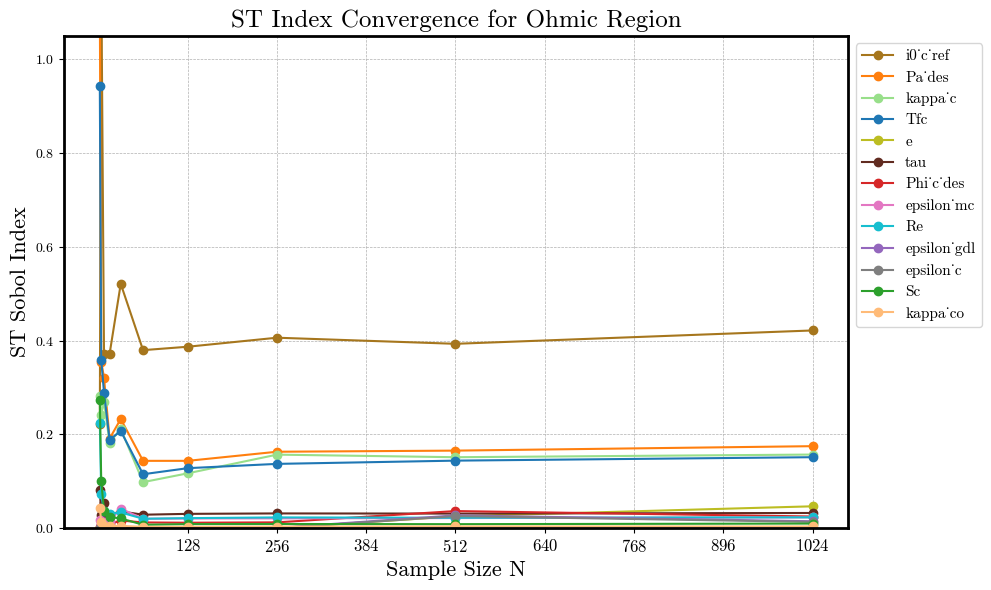

In [37]:

# Plot convergence
plot_sobol_index_convergence(sobol_convergence_ohmic, index_type="ST", region="ohmic", top_k=13)

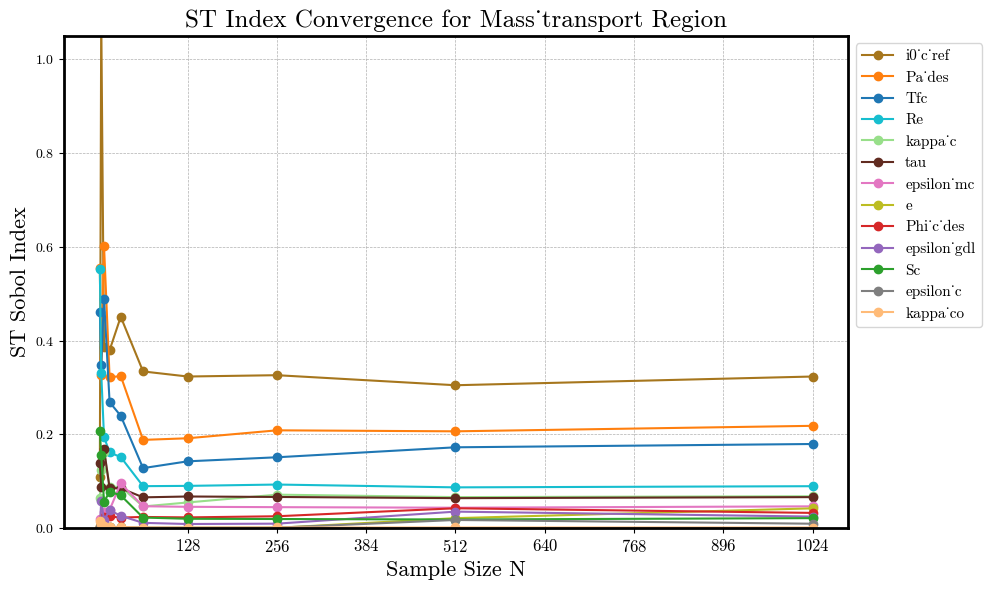

In [38]:

# Plot convergence
plot_sobol_index_convergence(sobol_convergence_mass, index_type="ST", region="mass_transport", top_k=13)

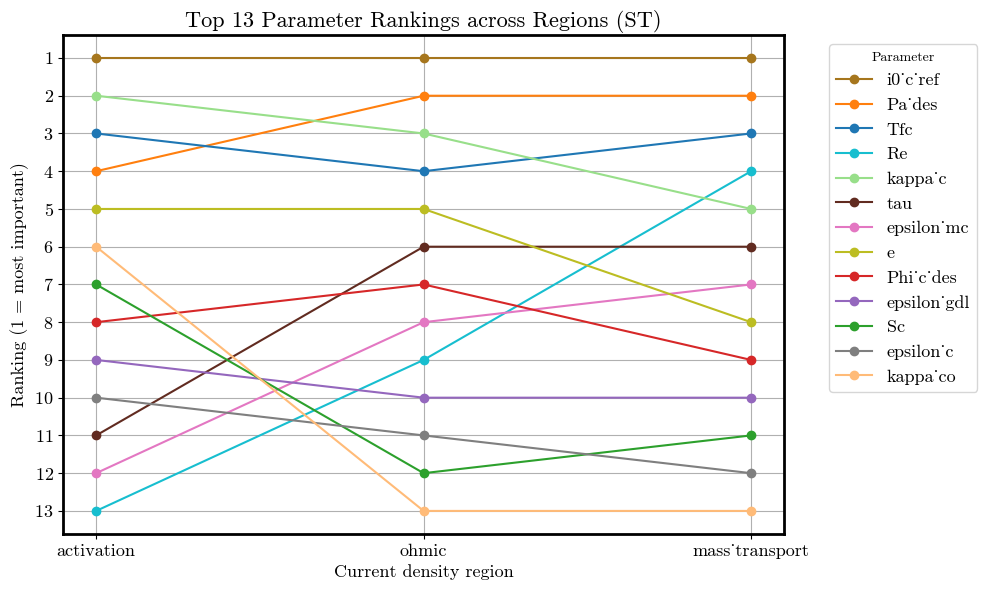

In [39]:
sobol_convergence_ohmic = run_sobol_convergence_analysis(df_merged["AUC_ohmic"], problem, step=2, max_N=1024, index_type="ST")
sobol_convergence_activation = run_sobol_convergence_analysis(df_merged["AUC_activation"], problem, step=2, max_N=1024, index_type="ST")
sobol_convergence_mass = run_sobol_convergence_analysis(df_merged["AUC_mass_transport"], problem, step=2, max_N=1024, index_type="ST")

# Extract final ST DataFrame from each convergence result
rank_sources_st = {
    "activation": sobol_convergence_activation[max(sobol_convergence_activation.keys())]["sobol_df"],
    "ohmic": sobol_convergence_ohmic[max(sobol_convergence_ohmic.keys())]["sobol_df"],
    "mass_transport": sobol_convergence_mass[max(sobol_convergence_mass.keys())]["sobol_df"]
}

plot_top_k_rankings_across_regions(
    rank_sources=rank_sources_st,
    source_type="ST",        # Choose "S1", "ST", or "shap"
    top_k=13,                # How many top features to track
    figsize=(10, 6)
)

In [42]:
# Run convergence for activation region 
sobol_convergence_activation_S1 = run_sobol_convergence_analysis(df_merged["AUC_activation"], problem, step=2, max_N=1024, index_type="S1")
sobol_convergence_ohmic_S1 = run_sobol_convergence_analysis(df_merged["AUC_ohmic"], problem, step=2, max_N=1024, index_type="S1")
sobol_convergence_mass_S1 = run_sobol_convergence_analysis(df_merged["AUC_mass_transport"], problem, step=2, max_N=1024, index_type="S1")

In [43]:
sobol_convergence_mass_S1[max(sobol_convergence_mass_S1.keys())]["sobol_df"].sort_values(by = "S1")

,S1,S1_conf,feature
epsilon_c,-0.005150,0.004227,epsilon_c
epsilon_gdl,-0.004719,0.009443,epsilon_gdl
Sc,-0.002015,0.012841,Sc
e,-0.000094,0.013478,e
kappa_co,0.000160,0.003229,kappa_co
Phi_c_des,0.004596,0.012886,Phi_c_des
epsilon_mc,0.036907,0.018111,epsilon_mc
kappa_c,0.043410,0.021094,kappa_c
tau,0.061670,0.025595,tau
Re,0.087217,0.026406,Re


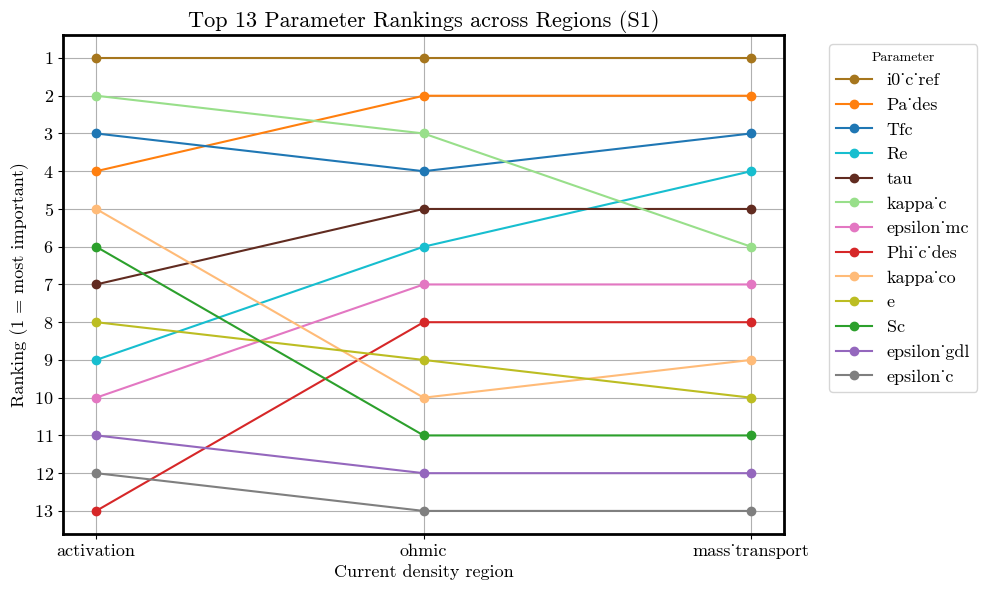

In [44]:
# Extract final ST DataFrame from each convergence result
rank_sources_s1 = {
    "activation": sobol_convergence_activation_S1[max(sobol_convergence_activation_S1.keys())]["sobol_df"],
    "ohmic": sobol_convergence_ohmic_S1[max(sobol_convergence_ohmic_S1.keys())]["sobol_df"],
    "mass_transport": sobol_convergence_mass_S1[max(sobol_convergence_mass_S1.keys())]["sobol_df"]
}

plot_top_k_rankings_across_regions(
    rank_sources=rank_sources_s1,
    source_type="S1",        # Choose "S1", "ST", or "shap"
    top_k=13,                # How many top features to track
    figsize=(10, 6)
)

### Generating the outputs that we need

In [30]:
first_Si_mass

,S1,S1_conf,CI_lower,CI_upper,CI_contains_0
Tfc,0.143871,0.036151,0.107720,0.180022,False
Pa_des,0.176420,0.036873,0.139547,0.213293,False
Sc,-0.002015,0.011749,-0.013764,0.009733,True
Phi_c_des,0.004596,0.013969,-0.009373,0.018565,True
epsilon_gdl,-0.004719,0.010613,-0.015332,0.005894,True
tau,0.061670,0.022103,0.039567,0.083774,False
epsilon_mc,0.036907,0.020350,0.016558,0.057257,False
epsilon_c,-0.005150,0.004831,-0.009981,-0.000320,False
e,-0.000094,0.014490,-0.014584,0.014396,True
Re,0.087217,0.025567,0.061650,0.112784,False


In [ ]:
region_to_df_S1 = {
    "activation": first_Si_activation,
    "ohmic": first_Si_ohmic,
    "mass_transport": first_Si_mass
}

region_to_df_ST = {
    "activation": total_Si_activation,
    "ohmic": total_Si_ohmic,
    "mass_transport": total_Si_mass
}

# Order in the presentation
param_order = [
    "Tfc", "Pa_des", "Sc", "Phi_c_des", "epsilon_gdl", "tau", "epsilon_mc",
    "epsilon_c", "e", "Re", "i0_c_ref", "kappa_co", "kappa_c"
]

In [33]:
summary_table_S1 = build_sobol_summary_table(region_to_df_S1, param_order, index_type="S1")
summary_table_S1

,activation_value,ohmic_value,mass_transport_value,activation_rank,ohmic_rank,mass_transport_rank
Parameter,,,,,,
Tfc,0.085 ± 0.03,0.133 ± 0.03,0.144 ± 0.04,3,4,3
Pa_des,0.059 ± 0.02,0.156 ± 0.04,0.176 ± 0.04,4,2,2
Sc,0.008 ± 0.01,0.000 ± 0.01,-0.002 ± 0.01,6,11,11
Phi_c_des,0.000 ± 0.00,0.004 ± 0.01,0.005 ± 0.01,13,8,8
epsilon_gdl,0.001 ± 0.00,-0.001 ± 0.00,-0.005 ± 0.01,11,12,12
tau,0.005 ± 0.01,0.030 ± 0.02,0.062 ± 0.02,7,5,5
epsilon_mc,0.002 ± 0.01,0.015 ± 0.01,0.037 ± 0.02,10,7,7
epsilon_c,0.001 ± 0.00,-0.001 ± 0.00,-0.005 ± 0.00,12,13,13
e,0.004 ± 0.01,0.003 ± 0.02,-0.000 ± 0.01,8,9,10


In [34]:
summary_table_ST = build_sobol_summary_table(region_to_df_S1, param_order, index_type="S1")
summary_table_ST

,activation_value,ohmic_value,mass_transport_value,activation_rank,ohmic_rank,mass_transport_rank
Parameter,,,,,,
Tfc,0.085 ± 0.03,0.133 ± 0.03,0.144 ± 0.04,3,4,3
Pa_des,0.059 ± 0.02,0.156 ± 0.04,0.176 ± 0.04,4,2,2
Sc,0.008 ± 0.01,0.000 ± 0.01,-0.002 ± 0.01,6,11,11
Phi_c_des,0.000 ± 0.00,0.004 ± 0.01,0.005 ± 0.01,13,8,8
epsilon_gdl,0.001 ± 0.00,-0.001 ± 0.00,-0.005 ± 0.01,11,12,12
tau,0.005 ± 0.01,0.030 ± 0.02,0.062 ± 0.02,7,5,5
epsilon_mc,0.002 ± 0.01,0.015 ± 0.01,0.037 ± 0.02,10,7,7
epsilon_c,0.001 ± 0.00,-0.001 ± 0.00,-0.005 ± 0.00,12,13,13
e,0.004 ± 0.01,0.003 ± 0.02,-0.000 ± 0.01,8,9,10


### Plots

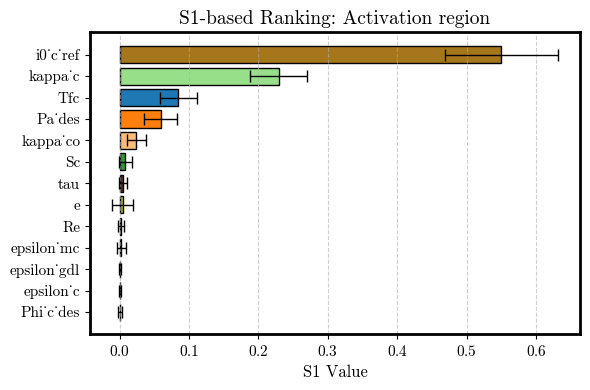

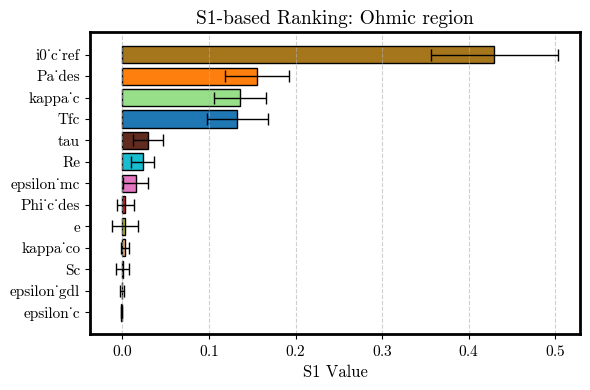

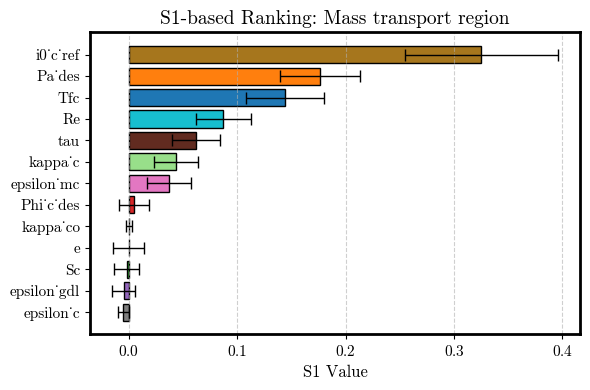

In [35]:
plot_sobol_region_barplot(first_Si_activation, region="activation", index_type="S1", top_k = 13)
plot_sobol_region_barplot(first_Si_ohmic, region="ohmic", index_type="S1", top_k = 13)
plot_sobol_region_barplot(first_Si_mass, region="mass transport", index_type="S1", top_k = 13)

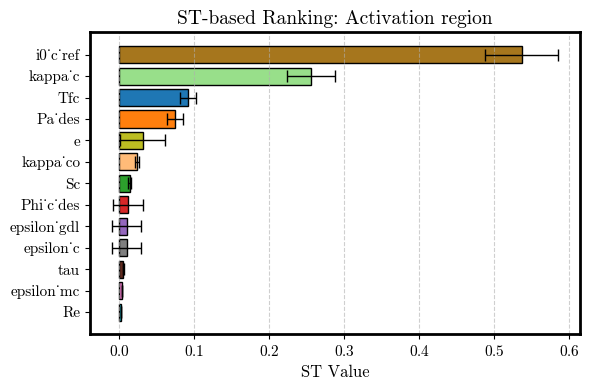

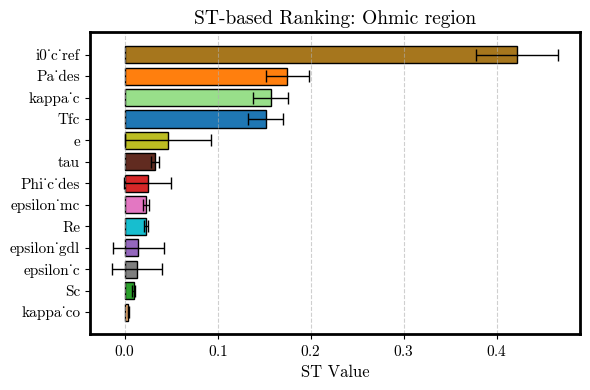

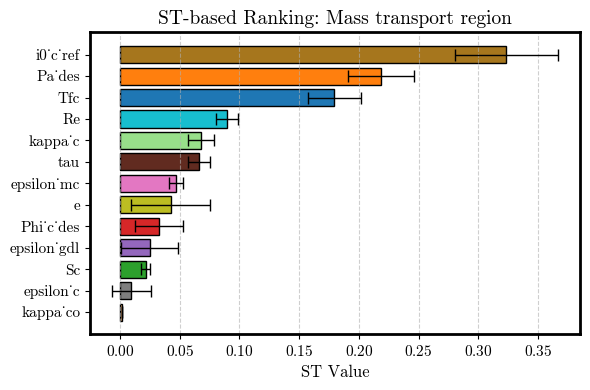

In [36]:
plot_sobol_region_barplot(total_Si_activation, region="activation", index_type="ST", top_k = 13)
plot_sobol_region_barplot(total_Si_ohmic, region="ohmic", index_type="ST", top_k = 13)
plot_sobol_region_barplot(total_Si_mass, region="mass transport", index_type="ST", top_k = 13)

In [49]:
second_Si_activation.sort_values(by = "S2", ascending = False)

,S2,S2_conf,CI_lower,CI_upper,CI_contains_0
"(Tfc, i0_c_ref)",0.010490,0.055374,-0.044884,0.065864,True
"(Sc, e)",0.007701,0.016965,-0.009264,0.024666,True
"(Sc, epsilon_mc)",0.005830,0.016833,-0.011002,0.022663,True
"(Sc, Phi_c_des)",0.005750,0.016890,-0.011140,0.022639,True
"(Sc, epsilon_gdl)",0.005697,0.016863,-0.011165,0.022560,True
...,...,...,...,...,...
"(Pa_des, epsilon_gdl)",-0.017011,0.033904,-0.050914,0.016893,True
"(i0_c_ref, kappa_co)",-0.017171,0.147183,-0.164354,0.130011,True
"(Pa_des, e)",-0.017195,0.033981,-0.051176,0.016786,True
"(i0_c_ref, kappa_c)",-0.021935,0.153553,-0.175487,0.131618,True


In [50]:
first_Si_activation.sort_values(by = "S1", ascending = False)

,S1,S1_conf,CI_lower,CI_upper,CI_contains_0
i0_c_ref,0.550017,0.081338,0.468679,0.631355,False
kappa_c,0.229282,0.040758,0.188524,0.270040,False
Tfc,0.084611,0.027046,0.057565,0.111658,False
Pa_des,0.059162,0.024029,0.035133,0.083190,False
kappa_co,0.024007,0.013688,0.010320,0.037695,False
Sc,0.007796,0.009379,-0.001583,0.017175,True
tau,0.004652,0.005828,-0.001175,0.010480,True
e,0.004250,0.014931,-0.010682,0.019181,True
Re,0.002390,0.004132,-0.001742,0.006522,True
epsilon_mc,0.002251,0.006371,-0.004120,0.008622,True


In [94]:
select_top_features(rank_sources=rank_sources_s1, source_type="S1", method="threshold", threshold=0.85)


Region: activation
Selected 3 features using method='threshold' (threshold=0.85)
Total importance explained: 0.891
Selected features: ['i0_c_ref', 'kappa_c', 'Tfc']

Region: ohmic
Selected 4 features using method='threshold' (threshold=0.85)
Total importance explained: 0.918
Selected features: ['i0_c_ref', 'Pa_des', 'kappa_c', 'Tfc']

Region: mass_transport
Selected 5 features using method='threshold' (threshold=0.85)
Total importance explained: 0.916
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'kappa_c', 'tau']
Total unique features selected: 6


({'activation': ['i0_c_ref', 'kappa_c', 'Tfc'],
  'ohmic': ['i0_c_ref', 'Pa_des', 'kappa_c', 'Tfc'],
  'mass_transport': ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau']},
 {'Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'kappa_c', 'tau'})

In [96]:
select_top_features(rank_sources=rank_sources_s1, source_type="S1", method="threshold", threshold=0.85)

,feature,importance,cumulative,cumulative_norm
0,i0_c_ref,0.550017,0.550017,0.566976
1,kappa_c,0.229282,0.779299,0.803328
2,Tfc,0.084611,0.863911,0.890548
3,Pa_des,0.059162,0.923072,0.951534
4,kappa_co,0.024007,0.947080,0.976282
5,Sc,0.007796,0.954876,0.984319
6,tau,0.004652,0.959528,0.989114
7,e,0.004250,0.963778,0.993495
8,Re,0.002390,0.966168,0.995959
9,epsilon_mc,0.002251,0.968419,0.998279


In [88]:
0.325114 +	0.176420 + 	0.176420 + 0.087217 + 0.061670 + 0.043410	

0.870251

In [73]:
first_Si_mass["S1"].sum()

np.float64(0.8673866921881692)

In [102]:
first_Si_ohmic.sort_values(by = "S1", ascending = False)

,S1,S1_conf,CI_lower,CI_upper,CI_contains_0
i0_c_ref,0.429455,0.073280,0.356175,0.502735,False
Pa_des,0.155809,0.037010,0.118800,0.192819,False
kappa_c,0.135513,0.029919,0.105594,0.165432,False
Tfc,0.132828,0.034809,0.098019,0.167637,False
tau,0.029820,0.017064,0.012756,0.046885,False
Re,0.023278,0.013436,0.009843,0.036714,False
epsilon_mc,0.015368,0.014357,0.001011,0.029726,False
Phi_c_des,0.003517,0.009589,-0.006072,0.013106,True
e,0.003338,0.015011,-0.011674,0.018349,True
kappa_co,0.003001,0.005143,-0.002142,0.008144,True


,feature,S1,S1_conf,CI_lower,CI_upper,CI_contains_0
0,Tfc,0.132828,0.034809,0.098019,0.167637,False
1,Pa_des,0.155809,0.037010,0.118800,0.192819,False
2,Sc,0.000279,0.007221,-0.006942,0.007501,True
3,Phi_c_des,0.003517,0.009589,-0.006072,0.013106,True
4,epsilon_gdl,-0.000745,0.002282,-0.003027,0.001537,True
5,tau,0.029820,0.017064,0.012756,0.046885,False
6,epsilon_mc,0.015368,0.014357,0.001011,0.029726,False
7,epsilon_c,-0.001157,0.000970,-0.002127,-0.000187,False
8,e,0.003338,0.015011,-0.011674,0.018349,True
9,Re,0.023278,0.013436,0.009843,0.036714,False


In [104]:
rank_sources_s1["mass_transport"].sort_values(by = "S1", ascending = False)

,S1,S1_conf,feature
i0_c_ref,0.325114,0.059795,i0_c_ref
Pa_des,0.176420,0.044889,Pa_des
Tfc,0.143871,0.039934,Tfc
Re,0.087217,0.026254,Re
tau,0.061670,0.020807,tau
kappa_c,0.043410,0.021965,kappa_c
epsilon_mc,0.036907,0.020740,epsilon_mc
Phi_c_des,0.004596,0.011443,Phi_c_des
kappa_co,0.000160,0.003647,kappa_co
e,-0.000094,0.016819,e


In [98]:
select_top_features(rank_sources=rank_sources_s1, source_type="S1", method="threshold", threshold=0.85)

,feature,importance,cumulative,cumulative_norm
0,i0_c_ref,0.325114,0.325114,0.374820
1,Pa_des,0.176420,0.501534,0.578213
2,Tfc,0.143871,0.645405,0.744080
3,Re,0.087217,0.732622,0.844632
4,tau,0.061670,0.794293,0.915731
5,kappa_c,0.043410,0.837703,0.965778
6,epsilon_mc,0.036907,0.874610,1.008328
7,Phi_c_des,0.004596,0.879206,1.013626
8,kappa_co,0.000160,0.879366,1.013810
9,e,-0.000094,0.879272,1.013702


In [118]:
select_top_features(rank_sources=rank_sources_s1, source_type="S1", method="threshold", threshold=0.85)

activation
        feature  importance  cumulative  cumulative_norm
0      i0_c_ref    0.550017    0.550017         0.566976
1       kappa_c    0.229282    0.779299         0.803328
2           Tfc    0.084611    0.863911         0.890548
3        Pa_des    0.059162    0.923072         0.951534
4      kappa_co    0.024007    0.947080         0.976282
5            Sc    0.007796    0.954876         0.984319
6           tau    0.004652    0.959528         0.989114
7             e    0.004250    0.963778         0.993495
8            Re    0.002390    0.966168         0.995959
9    epsilon_mc    0.002251    0.968419         0.998279
10  epsilon_gdl    0.000796    0.969215         0.999099
11    epsilon_c    0.000761    0.969976         0.999884
12    Phi_c_des    0.000112    0.970088         1.000000

Region: activation
Selected 3 features using method='threshold' (threshold=0.85)
Total importance explained: 0.891
Selected features: ['i0_c_ref', 'kappa_c', 'Tfc']
ohmic
        feature  im

({'activation': ['i0_c_ref', 'kappa_c', 'Tfc'],
  'ohmic': ['i0_c_ref', 'Pa_des', 'kappa_c', 'Tfc'],
  'mass_transport': ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau']},
 {'Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'kappa_c', 'tau'})

In [115]:
# Extract final ST DataFrame from each convergence result
rank_sources_s1 = {
    "activation": first_Si_activation.reset_index().rename(columns = {"index": "feature"}),
    "ohmic": first_Si_ohmic.reset_index().rename(columns = {"index": "feature"}),
    "mass_transport": first_Si_mass.reset_index().rename(columns = {"index": "feature"})
}

In [125]:
select_top_features(rank_sources=rank_sources_s1, source_type="S1", method="threshold", threshold=0.85)


Region: activation
Selected 3 features using method='threshold' (threshold=0.85)
Total importance explained: 0.864
Selected features: ['i0_c_ref', 'kappa_c', 'Tfc']

Region: ohmic
Selected 4 features using method='threshold' (threshold=0.85)
Total importance explained: 0.854
Selected features: ['i0_c_ref', 'Pa_des', 'kappa_c', 'Tfc']

Region: mass_transport
Selected 7 features using method='threshold' (threshold=0.85)
Total importance explained: 0.875
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau', 'kappa_c', 'epsilon_mc']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'kappa_c', 'tau']
Total unique features selected: 7


({'activation': ['i0_c_ref', 'kappa_c', 'Tfc'],
  'ohmic': ['i0_c_ref', 'Pa_des', 'kappa_c', 'Tfc'],
  'mass_transport': ['i0_c_ref',
   'Pa_des',
   'Tfc',
   'Re',
   'tau',
   'kappa_c',
   'epsilon_mc']},
 {'Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'kappa_c', 'tau'})

In [135]:
second_Si_activation["S2"].sum()

np.float64(-0.16602207592505377)

In [139]:
second_Si_activation[(second_Si_activation["S2"]>0) & (second_Si_activation["CI_contains_0"] == False)]["S2"].sum()

np.float64(0.0)